<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [5]:
import os
print(os.listdir('..'))

['learning', 'your-code', 'README.md', '.git', 'data']


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [9]:
customers = pd.read_csv('../data/Wholesale customers data.csv')

In [11]:

print(customers.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [12]:
# Descriptive statistics - check for outliers and skewness
print(customers.describe())

          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000        256.750000    408.

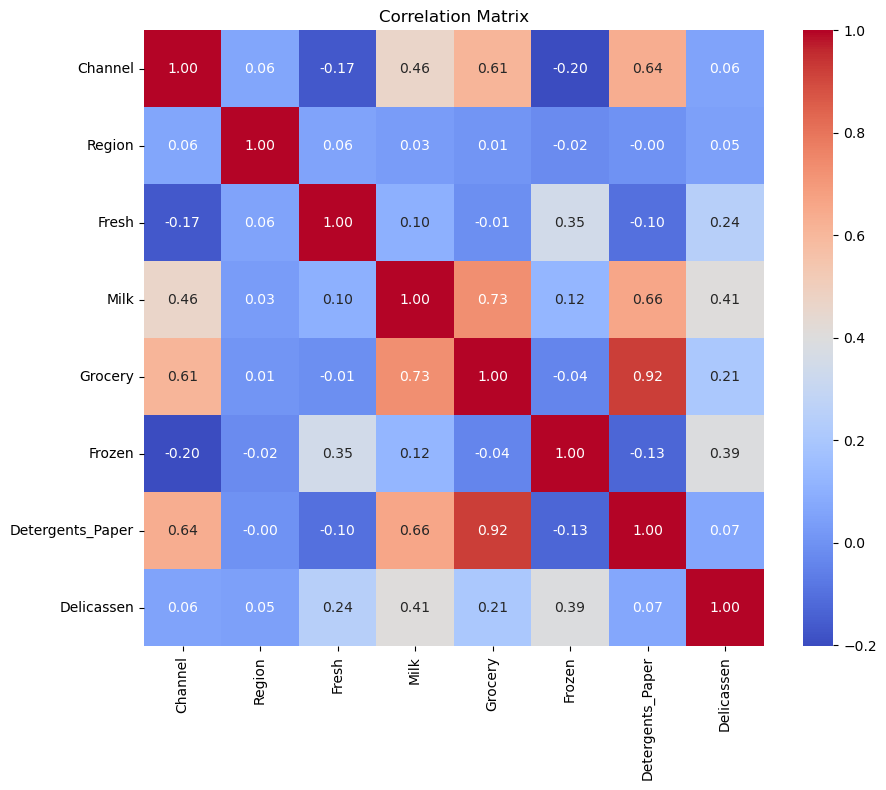

In [13]:
# Correlation heatmap - collinearity
plt.figure(figsize=(10, 8))
sns.heatmap(customers.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# Grocery and Detergents_Paper are highly correlated (~0.92)

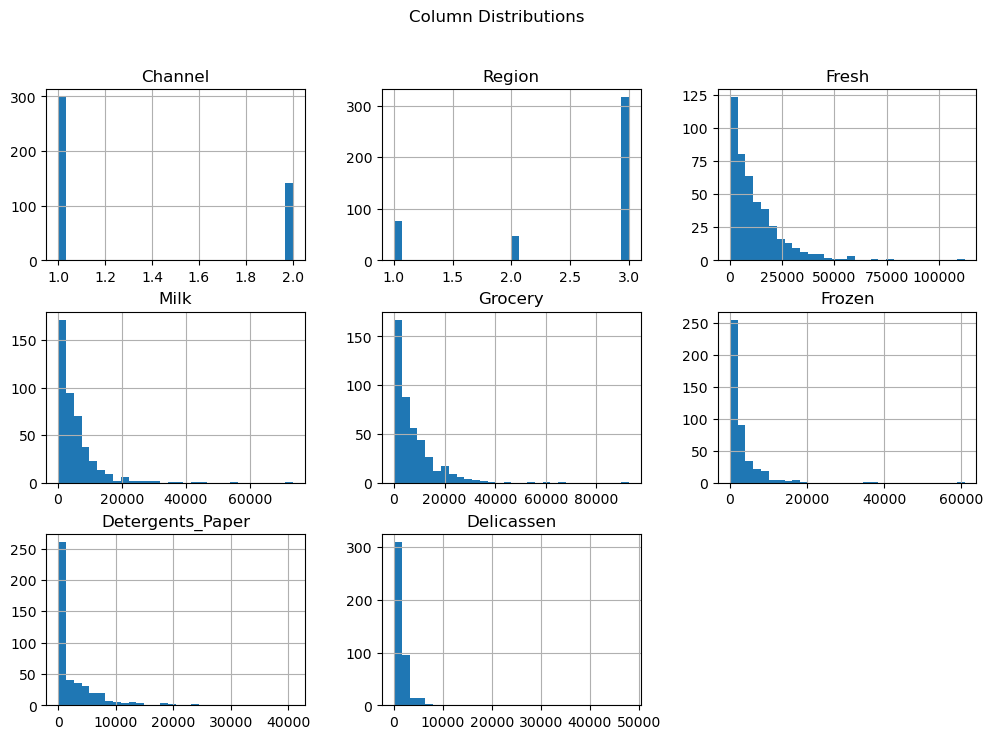

Top 20% of customers account for 42.9% of total spend


In [14]:
# Distribution - check skewness
customers.hist(figsize=(12, 8), bins=30)
plt.suptitle('Column Distributions')
plt.show()
# Most columns are right-skewed (long tail to the right)
# A few big spenders drive the distribution - consistent with Pareto principle

# Pareto check: top 20% of customers by total spend
customers['total'] = customers.sum(axis=1)
customers_sorted = customers.sort_values('total', ascending=False)
top_20_pct = int(len(customers_sorted) * 0.2)
top_20_spend = customers_sorted.head(top_20_pct)['total'].sum()
total_spend = customers_sorted['total'].sum()
print(f"Top 20% of customers account for {top_20_spend/total_spend*100:.1f}% of total spend")
customers.drop(columns=['total'], inplace=True)

**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [15]:
# No missing values or categorical columns to transform.
# Channel and Region are categorical but not useful for clustering spending patterns.
# We will drop them.
customers.drop(columns=['Channel', 'Region'], inplace=True)

# Comment: The dataset is clean. We only drop Channel and Region because
# they are category identifiers, not spending features.
print(customers.shape)

(440, 6)


**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
customers_scale = scaler.fit_transform(customers)

# StandardScaler transforms each feature to have mean=0 and std=1
# This prevents features with large ranges (Fresh, Grocery) from dominating the clustering
print("Scaled data shape:", customers_scale.shape)
print("Mean per column:", customers_scale.mean(axis=0).round(2))
print("Std per column:", customers_scale.std(axis=0).round(2))

Scaled data shape: (440, 6)
Mean per column: [-0.  0. -0.  0.  0. -0.]
Std per column: [1. 1. 1. 1. 1. 1.]


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

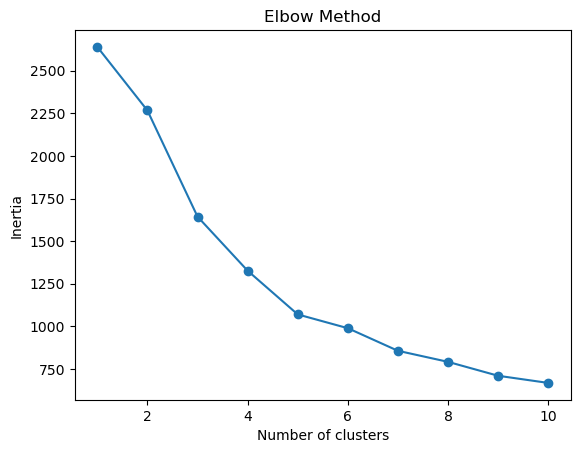

In [17]:
from sklearn.cluster import KMeans

# Elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(customers_scale)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
# The elbow appears around k=2, so we use n_clusters=2

### Looking to the elbow we can choose 2 like the correct number of clusters

In [18]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [20]:
# Already given in lab — assign labels back to customers
clean_customers = customers.copy()
clean_customers['Label'] = clusters

Count the values in `labels`.

In [21]:
# Count values in labels
print(pd.Series(labels).value_counts())

0    389
1     51
Name: count, dtype: int64


# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5)
dbscan.fit(customers_scale)

labels_DBSCAN = dbscan.labels_
customers['labels_DBSCAN'] = labels_DBSCAN


Count the values in `labels_DBSCAN`.

In [23]:
# Count values in labels_DBSCAN
print(pd.Series(labels_DBSCAN).value_counts())
# -1 means noise points (not assigned to any cluster)

 0    261
-1    174
 1      5
Name: count, dtype: int64


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [28]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

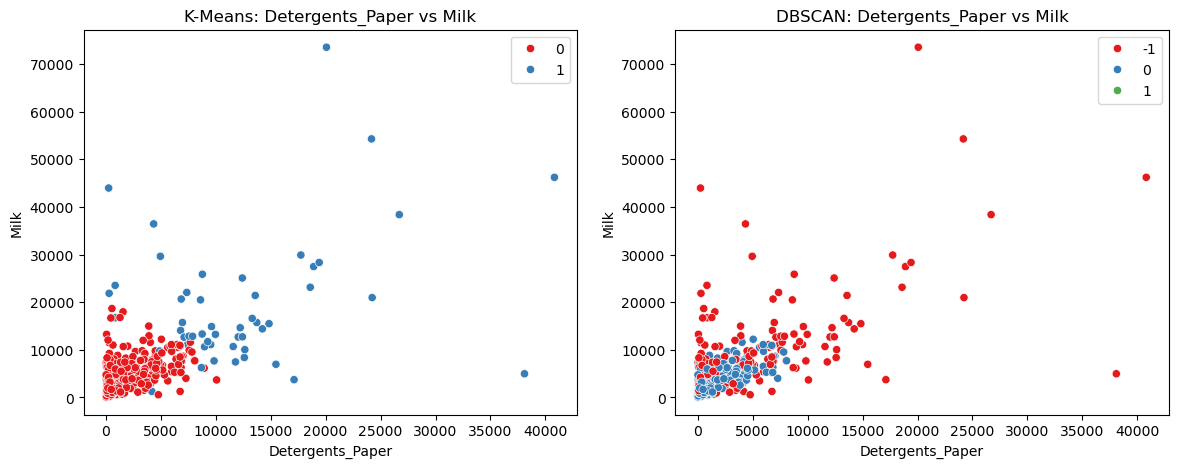

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=customers['Detergents_Paper'], y=customers['Milk'],
                hue=labels, ax=axes[0], palette='Set1')
axes[0].set_title('K-Means: Detergents_Paper vs Milk')

sns.scatterplot(x=customers['Detergents_Paper'], y=customers['Milk'],
                hue=labels_DBSCAN, ax=axes[1], palette='Set1')
axes[1].set_title('DBSCAN: Detergents_Paper vs Milk')
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

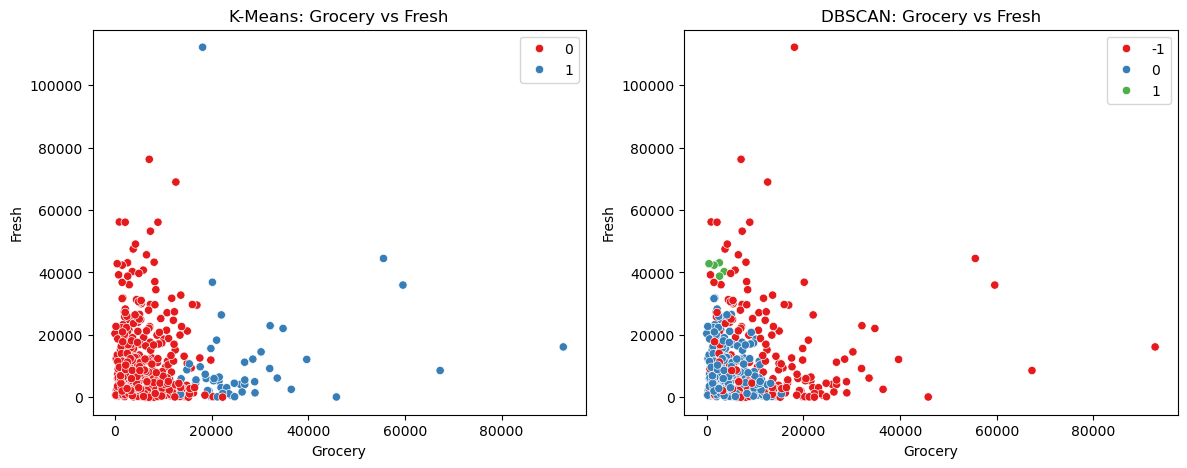

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=customers['Grocery'], y=customers['Fresh'],
                hue=labels, ax=axes[0], palette='Set1')
axes[0].set_title('K-Means: Grocery vs Fresh')

sns.scatterplot(x=customers['Grocery'], y=customers['Fresh'],
                hue=labels_DBSCAN, ax=axes[1], palette='Set1')
axes[1].set_title('DBSCAN: Grocery vs Fresh')
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

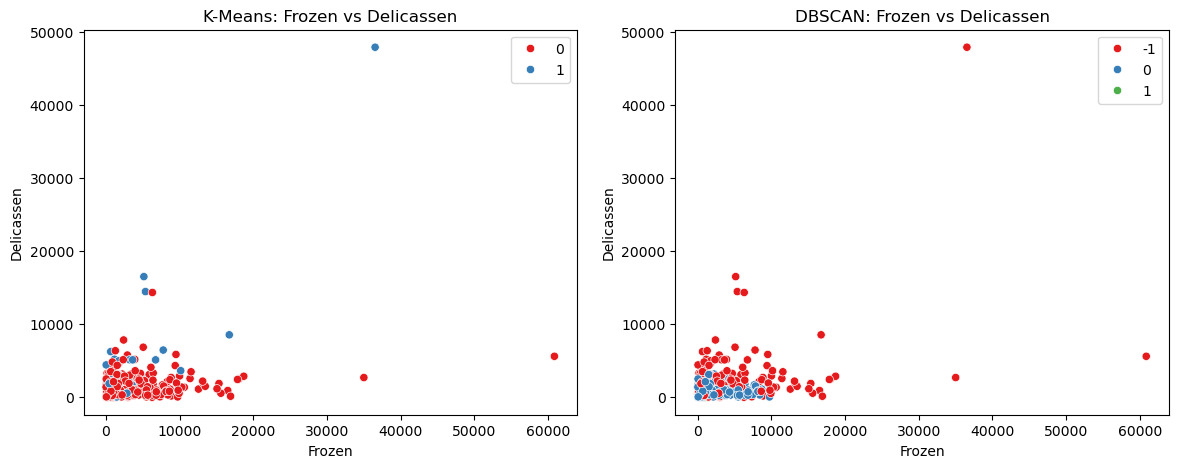

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=customers['Frozen'], y=customers['Delicassen'],
                hue=labels, ax=axes[0], palette='Set1')
axes[0].set_title('K-Means: Frozen vs Delicassen')

sns.scatterplot(x=customers['Frozen'], y=customers['Delicassen'],
                hue=labels_DBSCAN, ax=axes[1], palette='Set1')
axes[1].set_title('DBSCAN: Frozen vs Delicassen')
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [35]:
# Group by K-Means labels and compute means
print("K-Means group means:")
print(customers.groupby(labels).mean())

print("\nDBSCAN group means:")
print(customers.groupby(labels_DBSCAN).mean())

# K-Means gives 2 clean groups (0 and 1)
# DBSCAN group -1 represents noise points (outliers not assigned to any cluster)

K-Means group means:
          Fresh          Milk       Grocery       Frozen  Detergents_Paper  \
0  12157.300771   4028.169666   5402.722365  3066.066838       1667.688946   
1  10802.764706  19282.333333  27390.254902  3116.666667      12139.725490   

    Delicassen  labels_DBSCAN  
0  1256.894602      -0.303342  
1  3568.843137      -1.000000  

DBSCAN group means:
           Fresh          Milk       Grocery       Frozen  Detergents_Paper  \
-1  15608.988506  10000.408046  13693.298851  4786.275862       5291.373563   
 0   9030.398467   3077.318008   4234.061303  1963.432950       1322.134100   
 1  41446.600000   1421.200000   2167.600000  1276.400000        416.200000   

     Delicassen  labels_DBSCAN  
-1  2510.781609           -1.0  
 0   881.773946            0.0  
 1   784.800000            1.0  


Which algorithm appears to perform better?

**Your observations here**
K-Means produces cleaner, more balanced clusters. DBSCAN marks many points as noise (-1) with eps=0.5, which means that parameter may be too small for this dataset. K-Means appears to perform better visually for this data.


- 

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

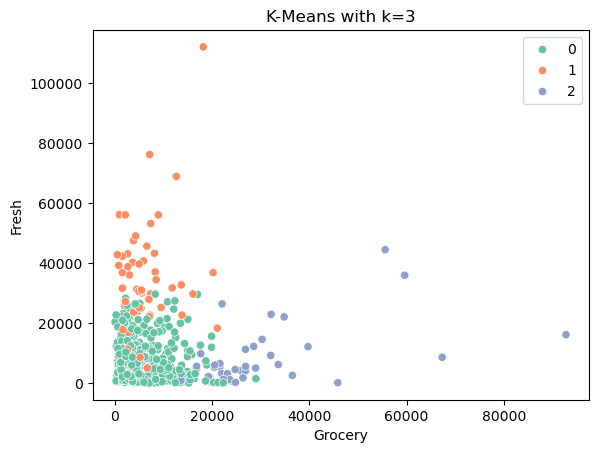

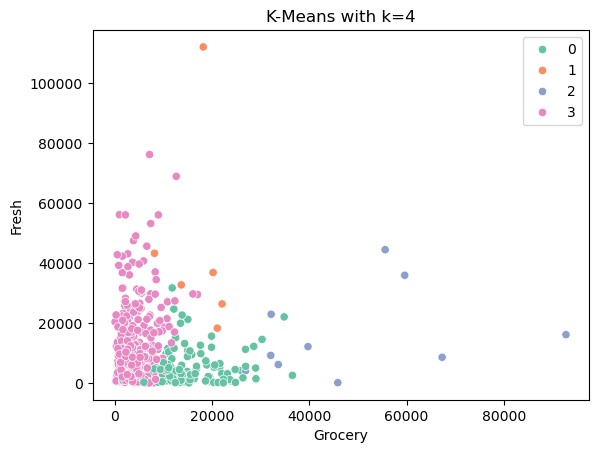

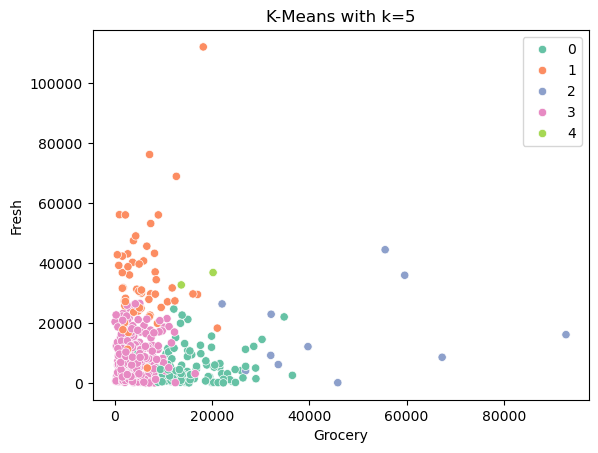

In [33]:
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(customers_scale)
    labels_k = km.labels_

    sns.scatterplot(x=customers['Grocery'], y=customers['Fresh'],
                    hue=labels_k, palette='Set2')
    plt.title(f'K-Means with k={k}')
    plt.show()

# Comment: k=3 seems to give more meaningful separations than k=2.
# k=4 and k=5 start to over-segment the data.

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

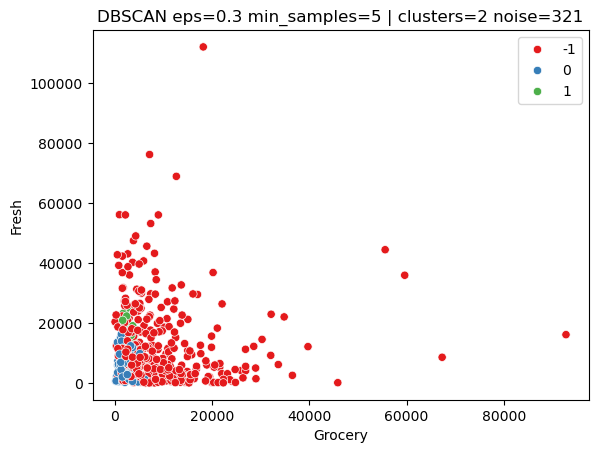

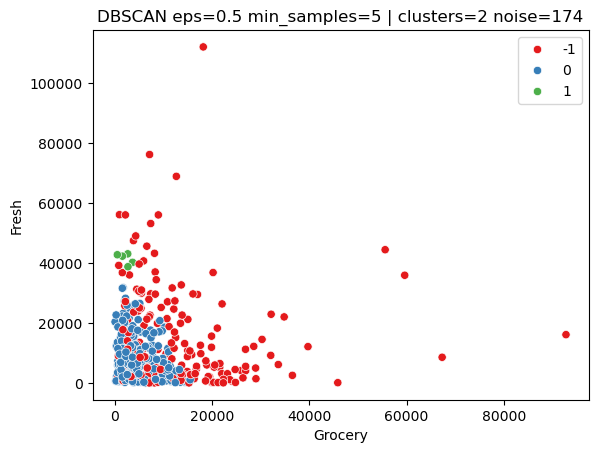

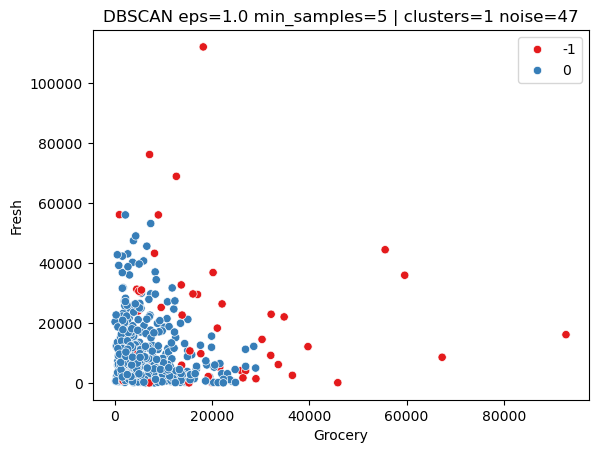

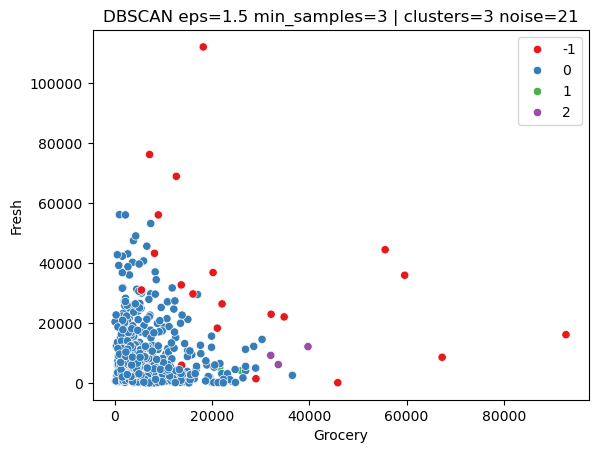

In [34]:
for eps_val, min_s in [(0.3, 5), (0.5, 5), (1.0, 5), (1.5, 3)]:
    db = DBSCAN(eps=eps_val, min_samples=min_s)
    db.fit(customers_scale)
    lbs = db.labels_

    n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_noise = list(lbs).count(-1)

    sns.scatterplot(x=customers['Grocery'], y=customers['Fresh'],
                    hue=lbs, palette='Set1')
    plt.title(f'DBSCAN eps={eps_val} min_samples={min_s} | clusters={n_clusters} noise={n_noise}')
    plt.show()

# Comment: Higher eps groups more points together and reduces noise.
# eps=1.0 or 1.5 gives more balanced clusters with less noise for this dataset.

**Your comment here**

- 